### [__Making PR and ROC Plots__](https://plotly.com/python/roc-and-pr-curves/)
--- 
* y_true will be the STRING scores ≥ 400 (True positives)
    * Check with gold standard

* y_score will either
     * ipTM score will be used to determine this 
        * Will double check ipTM gold standard 

[__Precision Recall Curve__](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)

Variable will be:
* precision
* recall
* thresholds
* pr_auc

[__Receiver Operating Characteristic__](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)

Varibles will be:
* fpr
* tpr
* thresholds
* auc_score

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [3]:
## load csv `graph`
final_comp = pl.scan_csv("final_comp.csv")

thresholds = [400, 600, 800, 900]
score_expr = (
    pl.col("combined_score")
    .cast(pl.String)
    .str.replace_all(",", "", literal=True)
    .cast(pl.Float64, strict=False)
)
## Adding a column that determines true positive
final_comp_sig = (
    final_comp
    .filter(pl.col("combined_score").is_not_null())
    .with_columns([
        (score_expr >= t).cast(pl.Int8).alias(f"gold_{t}")
        for t in thresholds
    ])
    .with_columns(
        y_score=score_expr / 1000
    )
)

In [21]:
final_comp_sig.collect().head()

protein1,protein2,chain_pair_iptm_best,chain_pair_iptm_mean,chain_pair_iptm_best_corrected,chain_pair_iptm_mean_corrected,string_id1,string_id2,combined_score,gold_400,gold_600,gold_800,gold_900,y_score
str,str,f64,f64,f64,f64,str,str,str,i8,i8,i8,i8,f64
"""p36040""","""q12034""",0.08,0.08,0.000253,0.000009,"""4932.YKL206C""","""4932.YDR515W""","""292""",0,0,0,0,0.292
"""p33322""","""p38701""",0.09,0.088,0.019846,0.017609,"""4932.YLR175W""","""4932.YHL015W""","""292""",0,0,0,0,0.292
"""p47171""","""q12510""",0.17,0.176,0.001389,0.007089,"""4932.YJR140C""","""4932.YDL156W""","""292""",0,0,0,0,0.292
"""p36517""","""q02555""",0.09,0.09,0.004051,0.003804,"""4932.YLR439W""","""4932.YMR239C""","""513""",1,0,0,0,0.513
"""p17106""","""q03071""",0.06,0.06,0.004893,0.004666,"""4932.YJR060W""","""4932.YPL046C""","""229""",0,0,0,0,0.229


In [10]:
# Setting up y_true and y_score
y_score = (
    final_comp_sig
    .select(pl.col("chain_pair_iptm_mean"))
    .collect()
    .to_numpy()
    .flatten()
)

y_true = (
    final_comp_sig
    .select(pl.col("gold_400").cast(pl.Int32, strict=False))
    .collect()
    .to_numpy()
    .flatten()
)

Precision Recall

In [11]:
# %pip install plotly.express
import plotly.express as px
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

In [12]:
#ploting interactive plot
fig = px.area(
    x=recall, y=precision,
    title=f'Precision-Recall Curve (AUC={auc(recall, precision):.4f})',
    labels=dict(x='Recall', y='Precision'),
    width=700, height=500
)
fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=1, y1=0
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')

fig.show()

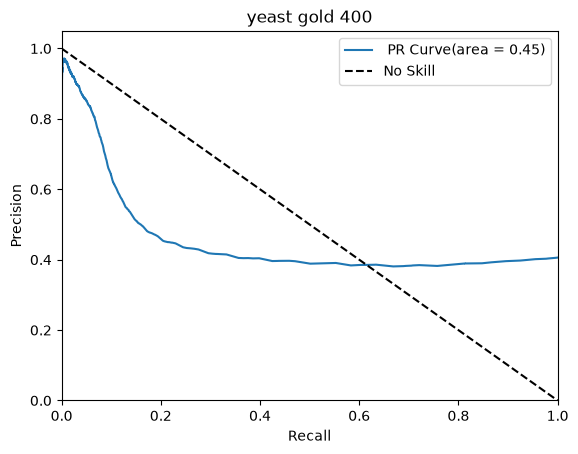

In [14]:
# non-interactive plot
plt.figure()  
plt.plot(recall, precision, label=' PR Curve(area = %0.2f)' % pr_auc)
plt.plot([0, 1], [1, 0], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('yeast gold 400')
plt.legend()
plt.show()

ROC

In [38]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc_score = roc_auc_score(y_true, y_score)
roc_auc = auc(fpr, tpr)

In [39]:
#ploting interactive plot
fig = px.area(
    x=fpr, y=tpr,
    title=f'ROC Curve (AUC={auc(fpr, tpr):.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700, height=500
)
fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show()

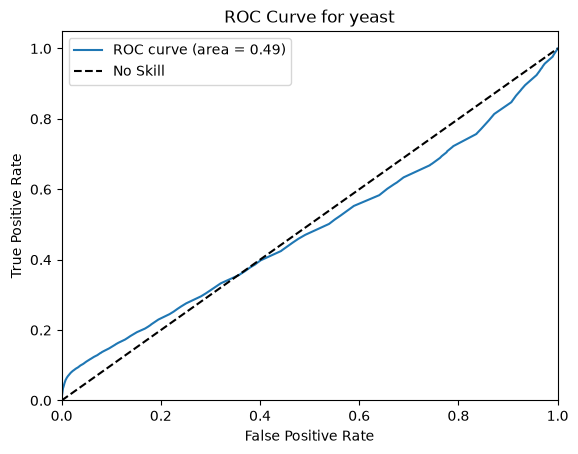

In [ ]:
#non interactive plot
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for yeast gold 400')
plt.legend()
plt.show()

Side-by-side comparrison

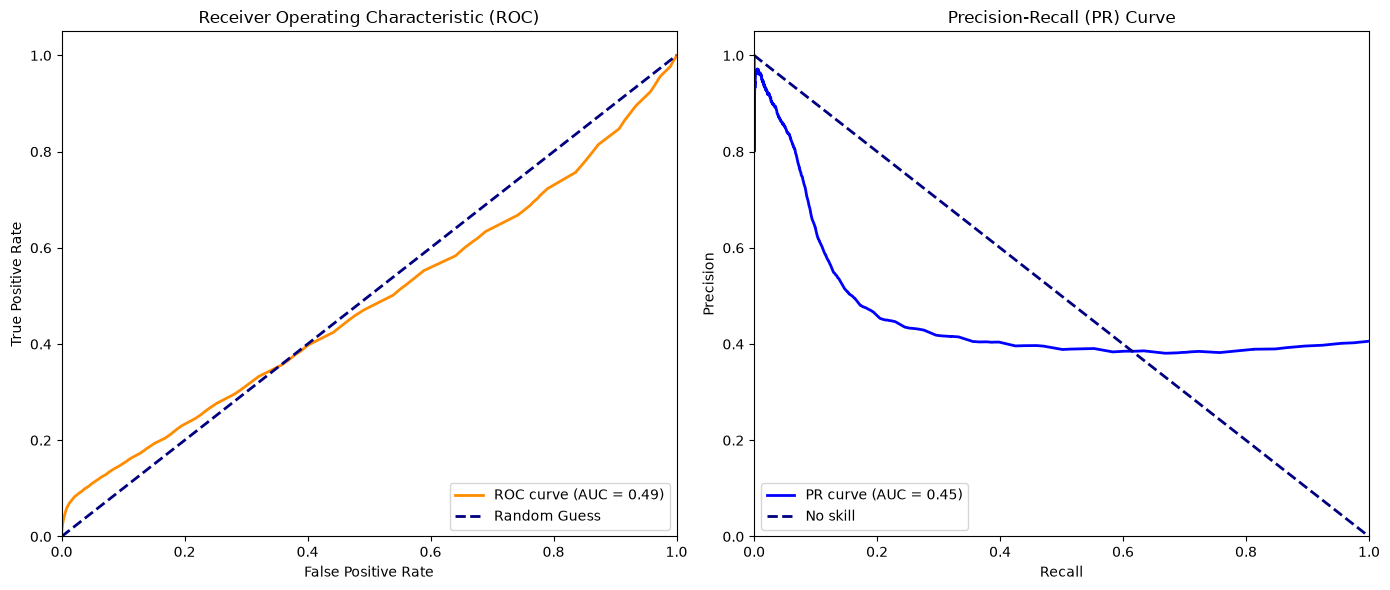

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve Plot
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# PR Curve Plot
ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
ax2.plot([0, 1], [1, 0], color='navy', lw=2, linestyle='--', label='No skill')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall (PR) Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

### __Interpertation of figures above__

__PR__:
With a heavily imbalanced dataset where positive cases are rare, the PR Area Under the Curve (AUC = 0.45) provides a conservative and highly realistic measure of performance, demonstrating that the model substantially outperforms a random baseline despite a sharp trade-off between minimizing false alarms and maximizing positive detections.

__ROC__:
There is an 49% chance that the model will rank a randomly chosen positive sample higher than a randomly chosen negative sample. 